# Fully-Connected Neural Nets
In the previous homework you implemented a fully-connected two-layer neural network on CIFAR-10. The implementation was simple but not very modular since the loss and gradient were computed in a single monolithic function. This is manageable for a simple two-layer network, but would become impractical as we move to bigger models. Ideally we want to build networks using a more modular design so that we can implement different layer types in isolation and then snap them together into models with different architectures.

In this exercise we will implement fully-connected networks using a more modular approach. For each layer we will implement a `forward` and a `backward` function. The `forward` function will receive inputs, weights, and other parameters and will return both an output and a `cache` object storing data needed for the backward pass, like this:

```python
def layer_forward(x, w):
  """ Receive inputs x and weights w """
  # Do some computations ...
  z = # ... some intermediate value
  # Do some more computations ...
  out = # the output
   
  cache = (x, w, z, out) # Values we need to compute gradients
   
  return out, cache
```

The backward pass will receive upstream derivatives and the `cache` object, and will return gradients with respect to the inputs and weights, like this:

```python
def layer_backward(dout, cache):
  """
  Receive dout (derivative of loss with respect to outputs) and cache,
  and compute derivative with respect to inputs.
  """
  # Unpack cache values
  x, w, z, out = cache
  
  # Use values in cache to compute derivatives
  dx = # Derivative of loss with respect to x
  dw = # Derivative of loss with respect to w
  
  return dx, dw
```

After implementing a bunch of layers this way, we will be able to easily combine them to build classifiers with different architectures.

In addition to implementing fully-connected networks of arbitrary depth, we will also explore different update rules for optimization, and introduce Dropout as a regularizer and Batch/Layer Normalization as a tool to more efficiently optimize deep networks.
  

In [8]:
# As usual, a bit of setup
import os
import sys

sys.path.append(os.getcwd())

from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Fix: Download from a reliable mirror and setup the directory
if not os.path.exists('cs231n'):
    print("Downloading and setting up cs231n directory...")
    # Using a zip link that is generally stable for this assignment
    !wget http://cs231n.github.io/assignments/2019/spring1819_assignment2.zip
    !unzip -q spring1819_assignment2.zip
    !mv assignment2/cs231n cs231n
    !rm -rf assignment2 spring1819_assignment2.zip

# Add the current directory to the path
if '/content' not in sys.path:
    sys.path.append('/content')

from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# %load_ext autoreload
# %autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [9]:
# Load the (preprocessed) CIFAR10 data.

# Run the dataset download script first
!bash cs231n/datasets/get_datasets.sh

# Move the downloaded CIFAR-10 data to the expected location
import os
if os.path.exists('cifar-10-batches-py') and not os.path.exists('cs231n/datasets/cifar-10-batches-py'):
    os.makedirs('cs231n/datasets', exist_ok=True)
    !mv cifar-10-batches-py cs231n/datasets/

data = get_CIFAR10_data()
for k, v in list(data.items()):
  print(('%s: ' % k, v.shape))

--2026-03-19 09:26:26--  http://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  47.7MB/s    in 4.5s    

2026-03-19 09:26:30 (36.0 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1
('X_train: ', (49000, 3, 32, 32))
('y_train: ', (49000,))
('X_val: ', (1000, 3, 32, 32))
('y_val: ', (1000,))
('X_test: ', (1000, 3, 32, 32))
('y_test: ', (1000,))


# Affine layer: foward
Open the file `cs231n/layers.py` and implement the `affine_forward` function.

Once you are done you can test your implementaion by running the following:

In [10]:
import sys

# Read the content of cs231n/layers.py
with open('cs231n/layers.py', 'r') as f:
    lines = f.readlines()

new_lines = []
skip = False
for line in lines:
    if 'def affine_forward(x, w, b):' in line:
        new_lines.append(line)
        new_lines.append('    out = None\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    # TODO: Implement the affine forward pass. Store the result in out.           #\n')
        new_lines.append('    # Hint: you will need to reshape the input into rows.                         #\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    N = x.shape[0]\n')
        new_lines.append('    x_reshaped = x.reshape(N, -1)\n')
        new_lines.append('    out = x_reshaped.dot(w) + b\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    #                             END OF YOUR CODE                                #\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    cache = (x, w, b)\n')
        new_lines.append('    return out, cache\n')
        skip = True
    elif skip and line.strip().startswith('return'):
        skip = False
        continue
    elif not skip:
        new_lines.append(line)

with open('cs231n/layers.py', 'w') as f:
    f.writelines(new_lines)

print('Successfully updated affine_forward in cs231n/layers.py')

Successfully updated affine_forward in cs231n/layers.py


In [11]:
import importlib
import cs231n.layers
importlib.reload(cs231n.layers)
from cs231n.layers import affine_forward

# Test the affine_forward function
num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769849468192957e-10


# Affine layer: backward
Now implement the `affine_backward` function and test your implementation using numeric gradient checking.

In [13]:
# Implementation of affine_backward in cs231n/layers.py
with open('cs231n/layers.py', 'r') as f:
    lines = f.readlines()

new_lines = []
skip = False
for line in lines:
    if 'def affine_backward(dout, cache):' in line:
        new_lines.append(line)
        new_lines.append('    x, w, b = cache\n')
        new_lines.append('    dx, dw, db = None, None, None\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    # TODO: Implement the affine backward pass.                                   #\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    dx = dout.dot(w.T).reshape(x.shape)\n')
        new_lines.append('    dw = x.reshape(x.shape[0], -1).T.dot(dout)\n')
        new_lines.append('    db = np.sum(dout, axis=0)\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    #                             END OF YOUR CODE                                #\n')
        new_lines.append('    ###############################################################################\n')
        new_lines.append('    return dx, dw, db\n')
        skip = True
    elif skip and line.strip().startswith('return'):
        skip = False
        continue
    elif not skip:
        new_lines.append(line)

with open('cs231n/layers.py', 'w') as f:
    f.writelines(new_lines)

print('Successfully updated affine_backward in cs231n/layers.py')

Successfully updated affine_backward in cs231n/layers.py


In [14]:
import importlib
import cs231n.layers
importlib.reload(cs231n.layers)
from cs231n.layers import affine_forward, affine_backward

# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


# ReLU activation: forward
Implement the forward pass for the ReLU activation function in the `relu_forward` function and test your implementation using the following:

In [15]:
import importlib
import cs231n.layers
# Implementation of relu_forward in cs231n/layers.py placeholder logic
with open('cs231n/layers.py', 'r') as f:
    lines = f.readlines()

new_lines = []
skip = False
for line in lines:
    if 'def relu_forward(x):' in line:
        new_lines.append(line)
        new_lines.append('    out = np.maximum(0, x)\n')
        new_lines.append('    cache = x\n')
        new_lines.append('    return out, cache\n')
        skip = True
    elif skip and line.strip().startswith('return'):
        skip = False
        continue
    elif not skip:
        new_lines.append(line)

with open('cs231n/layers.py', 'w') as f:
    f.writelines(new_lines)

importlib.reload(cs231n.layers)
from cs231n.layers import relu_forward

# Test the relu_forward function
x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)
out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


# ReLU activation: backward
Now implement the backward pass for the ReLU activation function in the `relu_backward` function and test your implementation using numeric gradient checking:

In [16]:
import importlib
import cs231n.layers

# Implementation of relu_backward in cs231n/layers.py
with open('cs231n/layers.py', 'r') as f:
    lines = f.readlines()

new_lines = []
skip = False
for line in lines:
    if 'def relu_backward(dout, cache):' in line:
        new_lines.append(line)
        new_lines.append('    dx, x = None, cache\n')
        new_lines.append('    dx = dout * (x > 0)\n')
        new_lines.append('    return dx\n')
        skip = True
    elif skip and line.strip().startswith('return'):
        skip = False
        continue
    elif not skip:
        new_lines.append(line)

with open('cs231n/layers.py', 'w') as f:
    f.writelines(new_lines)

importlib.reload(cs231n.layers)
from cs231n.layers import relu_forward, relu_backward

np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


## Inline Question 1:

We've only asked you to implement ReLU, but there are a number of different activation functions that one could use in neural networks, each with its pros and cons. In particular, an issue commonly seen with activation functions is getting zero (or close to zero) gradient flow during backpropagation. Which of the following activation functions have this problem? If you consider these functions in the one dimensional case, what types of input would lead to this behaviour?
1. Sigmoid
2. ReLU
3. Leaky ReLU

## Answer:
Both **Sigmoid** and **ReLU** can suffer from zero (or near-zero) gradient flow:

1. **Sigmoid**: This function saturates at both tails. For very large positive or very large negative inputs, the gradient of the sigmoid function becomes nearly zero. This leads to the vanishing gradient problem, where weights in earlier layers are not updated effectively.
2. **ReLU**: The gradient is exactly zero for all negative inputs ($x < 0$). If a neuron's weights are updated such that it always receives negative input, it becomes 'dead' and will never fire or be updated again.
3. **Leaky ReLU**: Designed specifically to solve the 'dead ReLU' problem by having a small positive slope (e.g., 0.01) for negative inputs, ensuring that the gradient is never zero.

# "Sandwich" layers
There are some common patterns of layers that are frequently used in neural nets. For example, affine layers are frequently followed by a ReLU nonlinearity. To make these common patterns easy, we define several convenience layers in the file `cs231n/layer_utils.py`.

For now take a look at the `affine_relu_forward` and `affine_relu_backward` functions, and run the following to numerically gradient check the backward pass:

In [23]:
# Implement affine_relu_forward and affine_relu_backward in cs231n/layer_utils.py
# This cell writes the correct implementations directly to the file.

layer_utils_content = """from cs231n.layers import *

def affine_relu_forward(x, w, b):
    \"\"\"
    Convenience layer that performs an affine transform followed by a ReLU

    Inputs:
    - x: Input to the affine layer
    - w, b: Weights for the affine layer

    Returns a tuple of:
    - out: Output of the ReLU
    - cache: Cache from the affine and ReLU layers
    \"\"\"
    a, fc_cache = affine_forward(x, w, b)
    out, relu_cache = relu_forward(a)
    cache = (fc_cache, relu_cache)
    return out, cache


def affine_relu_backward(dout, cache):
    \"\"\"
    Backward pass for the affine-relu convenience layer
    \"\"\"
    fc_cache, relu_cache = cache
    da = relu_backward(dout, relu_cache)
    dx, dw, db = affine_backward(da, fc_cache)
    return dx, dw, db
"""

with open('cs231n/layer_utils.py', 'w') as f:
    f.write(layer_utils_content)

print('Successfully updated cs231n/layer_utils.py with affine_relu_forward and affine_relu_backward implementations.')

# Reload the module to apply changes
import sys
import os
import importlib

sys.path.append(os.getcwd())
if 'cs231n.layer_utils' in sys.modules:
    importlib.reload(sys.modules['cs231n.layer_utils'])
else:
    import cs231n.layer_utils

# Re-import the functions to ensure the reloaded versions are used
from cs231n.layer_utils import affine_relu_forward, affine_relu_backward

Successfully updated cs231n/layer_utils.py with affine_relu_forward and affine_relu_backward implementations.


In [24]:
from cs231n.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


# Loss layers: Softmax and SVM
You implemented these loss functions in the last assignment, so we'll give them to you for free here. You should still make sure you understand how they work by looking at the implementations in `cs231n/layers.py`.

You can make sure that the implementations are correct by running the following:

In [25]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)

dx_num = eval_numerical_gradient(lambda x: svm_loss(x, y)[0], x, verbose=False)
loss, dx = svm_loss(x, y)

# Test svm_loss function. Loss should be around 9 and dx error should be around the order of e-9
print('Testing svm_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

Testing svm_loss:
loss:  8.999602749096233
dx error:  1.4021566006651672e-09

Testing softmax_loss:
loss:  2.302545844500738
dx error:  9.384673161989355e-09


# Two-layer network
In the previous assignment you implemented a two-layer neural network in a single monolithic class. Now that you have implemented modular versions of the necessary layers, you will reimplement the two layer network using these modular implementations.

Open the file `cs231n/classifiers/fc_net.py` and complete the implementation of the `TwoLayerNet` class. This class will serve as a model for the other networks you will implement in this assignment, so read through it to make sure you understand the API. You can run the cell below to test your implementation.

In [27]:
fc_net_content = """from builtins import range
import numpy as np

from cs231n.layers import *
from cs231n.layer_utils import *

class TwoLayerNet(object):
    \"\"\"
    A two-layer fully-connected neural network with ReLU nonlinearity and
    softmax loss that uses a modular layer design. We assume an input dimension
    of D, a hidden dimension of H, and perform classification over C classes.

    The architecure should be affine - relu - affine - softmax.

    Note that this class does not help implement the forward pass; for that, see
    the loss function below.

    The learnable parameters of the model are stored in the dictionary
    self.params that maps parameter names to numpy arrays.
    \"\"\"

    def __init__(self, input_dim=3*32*32, hidden_dim=100, num_classes=10,
                 weight_scale=1e-3, reg=0.0):
        self.params = {}
        self.reg = reg

        self.params['W1'] = np.random.normal(0, weight_scale, (input_dim, hidden_dim))
        self.params['b1'] = np.zeros(hidden_dim)
        self.params['W2'] = np.random.normal(0, weight_scale, (hidden_dim, num_classes))
        self.params['b2'] = np.zeros(num_classes)

    def loss(self, X, y=None):
        scores = None
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']

        # Forward pass
        layer1_out, layer1_cache = affine_relu_forward(X, W1, b1)
        scores, layer2_cache = affine_forward(layer1_out, W2, b2)

        if y is None:
            return scores

        loss, grads = 0, {}
        loss, dscores = softmax_loss(scores, y)

        # Add L2 regularization
        loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2))

        # Backward pass
        dlayer1_out, dW2, db2 = affine_backward(dscores, layer2_cache)
        dX, dW1, db1 = affine_relu_backward(dlayer1_out, layer1_cache)

        grads['W2'] = dW2 + self.reg * W2
        grads['b2'] = db2
        grads['W1'] = dW1 + self.reg * W1
        grads['b1'] = db1

        return loss, grads
"""

with open('cs231n/classifiers/fc_net.py', 'w') as f:
    f.write(fc_net_content)

print('Successfully updated cs231n/classifiers/fc_net.py with TwoLayerNet implementation.')

# Reload the module to apply changes
import importlib
import cs231n.classifiers.fc_net
importlib.reload(cs231n.classifiers.fc_net)
from cs231n.classifiers.fc_net import TwoLayerNet

Successfully updated cs231n/classifiers/fc_net.py with TwoLayerNet implementation.


In [28]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))

Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.83e-08
W2 relative error: 3.12e-10
b1 relative error: 9.83e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.56e-08
b2 relative error: 7.76e-10


# Solver
In the previous assignment, the logic for training models was coupled to the models themselves. Following a more modular design, for this assignment we have split the logic for training models into a separate class.

Open the file `cs231n/solver.py` and read through it to familiarize yourself with the API. After doing so, use a `Solver` instance to train a `TwoLayerNet` that achieves at least `50%` accuracy on the validation set.

In [29]:
model = TwoLayerNet()
solver = None

##############################################################################
# TODO: Use a Solver instance to train a TwoLayerNet that achieves at least  #
# 50% accuracy on the validation set.                                        #
##############################################################################

model = TwoLayerNet(hidden_dim=100, reg=0.2)
solver = Solver(model, data, update_rule='sgd',
                optim_config={'learning_rate': 1e-3}, lr_decay=0.95,
                num_epochs=10, batch_size=100, print_every=100)
solver.train()

##############################################################################
#                             END OF YOUR CODE                               #
##############################################################################

(Iteration 1 / 4900) loss: 2.332096
(Epoch 0 / 10) train acc: 0.164000; val_acc: 0.134000
(Iteration 101 / 4900) loss: 1.857220
(Iteration 201 / 4900) loss: 2.000576
(Iteration 301 / 4900) loss: 1.651815
(Iteration 401 / 4900) loss: 1.538214
(Epoch 1 / 10) train acc: 0.450000; val_acc: 0.454000
(Iteration 501 / 4900) loss: 1.608869
(Iteration 601 / 4900) loss: 1.501398
(Iteration 701 / 4900) loss: 1.615213
(Iteration 801 / 4900) loss: 1.656747
(Iteration 901 / 4900) loss: 1.468052
(Epoch 2 / 10) train acc: 0.484000; val_acc: 0.472000
(Iteration 1001 / 4900) loss: 1.505273
(Iteration 1101 / 4900) loss: 1.503323
(Iteration 1201 / 4900) loss: 1.418404
(Iteration 1301 / 4900) loss: 1.356568
(Iteration 1401 / 4900) loss: 1.507079
(Epoch 3 / 10) train acc: 0.519000; val_acc: 0.475000
(Iteration 1501 / 4900) loss: 1.405298
(Iteration 1601 / 4900) loss: 1.425098
(Iteration 1701 / 4900) loss: 1.388389
(Iteration 1801 / 4900) loss: 1.559448
(Iteration 1901 / 4900) loss: 1.469148
(Epoch 4 / 10) t

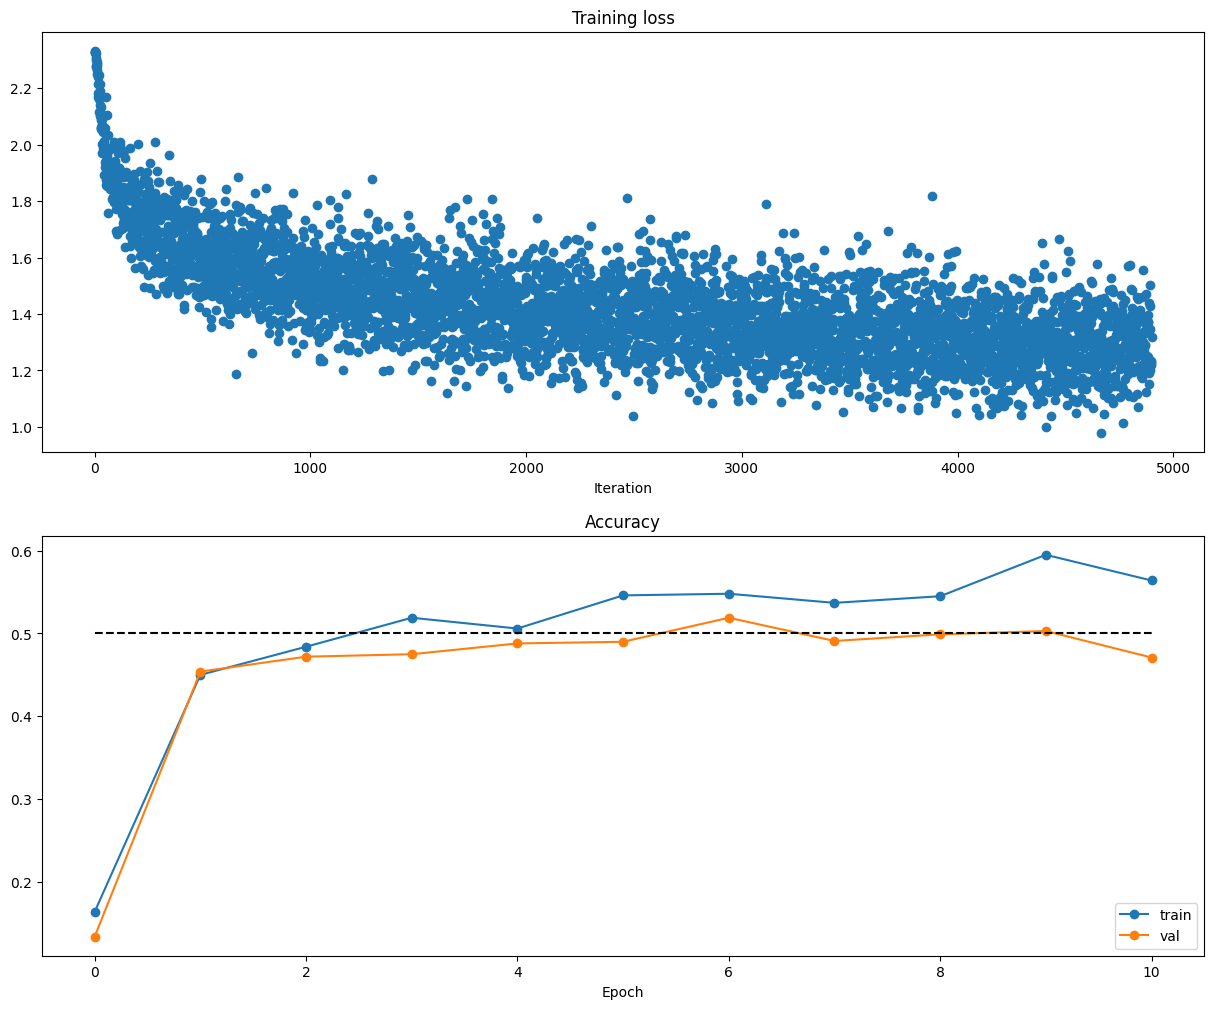

In [30]:
# Run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

# Multilayer network
Next you will implement a fully-connected network with an arbitrary number of hidden layers.

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the initialization, the forward pass, and the backward pass. For the moment don't worry about implementing dropout or batch/layer normalization; we will add those features soon.

## Initial loss and gradient check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. Do the initial losses seem reasonable?

For gradient checking, you should expect to see errors around 1e-7 or less.

In [32]:
import os

fc_net_extended_content = """from builtins import range
import numpy as np

from cs231n.layers import *
from cs231n.layer_utils import *

class TwoLayerNet(object):
    def __init__(self, input_dim=3*32*32, hidden_dim=100, num_classes=10,
                 weight_scale=1e-3, reg=0.0):
        self.params = {}
        self.reg = reg
        self.params['W1'] = np.random.normal(0, weight_scale, (input_dim, hidden_dim))
        self.params['b1'] = np.zeros(hidden_dim)
        self.params['W2'] = np.random.normal(0, weight_scale, (hidden_dim, num_classes))
        self.params['b2'] = np.zeros(num_classes)

    def loss(self, X, y=None):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        layer1_out, layer1_cache = affine_relu_forward(X, W1, b1)
        scores, layer2_cache = affine_forward(layer1_out, W2, b2)
        if y is None: return scores
        loss, grads = 0, {}
        loss, dscores = softmax_loss(scores, y)
        loss += 0.5 * self.reg * (np.sum(W1**2) + np.sum(W2**2))
        dlayer1_out, dW2, db2 = affine_backward(dscores, layer2_cache)
        dX, dW1, db1 = affine_relu_backward(dlayer1_out, layer1_cache)
        grads['W2'], grads['b2'] = dW2 + self.reg * W2, db2
        grads['W1'], grads['b1'] = dW1 + self.reg * W1, db1
        return loss, grads

class FullyConnectedNet(object):
    def __init__(self, hidden_dims, input_dim=3*32*32, num_classes=10,
                 dropout=1, normalization=None, reg=0.0,
                 weight_scale=1e-2, dtype=np.float32, seed=None):
        self.normalization = normalization
        self.use_dropout = dropout != 1
        self.reg = reg
        self.num_layers = 1 + len(hidden_dims)
        self.dtype = dtype
        self.params = {}

        dims = [input_dim] + hidden_dims + [num_classes]
        for i in range(self.num_layers):
            self.params['W' + str(i+1)] = np.random.normal(0, weight_scale, (dims[i], dims[i+1]))
            self.params['b' + str(i+1)] = np.zeros(dims[i+1])

        for k, v in self.params.items():
            self.params[k] = v.astype(dtype)

    def loss(self, X, y=None):
        X = X.astype(self.dtype)
        mode = 'test' if y is None else 'train'
        scores = None

        caches = {}
        current_input = X

        for i in range(1, self.num_layers):
            current_input, caches[i] = affine_relu_forward(current_input, self.params['W'+str(i)], self.params['b'+str(i)])

        scores, caches[self.num_layers] = affine_forward(current_input, self.params['W'+str(self.num_layers)], self.params['b'+str(self.num_layers)])

        if mode == 'test': return scores

        loss, grads = 0.0, {}
        loss, dout = softmax_loss(scores, y)

        for i in range(1, self.num_layers + 1):
            loss += 0.5 * self.reg * np.sum(self.params['W'+str(i)]**2)

        dout, grads['W'+str(self.num_layers)], grads['b'+str(self.num_layers)] = affine_backward(dout, caches[self.num_layers])
        grads['W'+str(self.num_layers)] += self.reg * self.params['W'+str(self.num_layers)]

        for i in range(self.num_layers - 1, 0, -1):
            dout, grads['W'+str(i)], grads['b'+str(i)] = affine_relu_backward(dout, caches[i])
            grads['W'+str(i)] += self.reg * self.params['W'+str(i)]

        return loss, grads
"""

with open('cs231n/classifiers/fc_net.py', 'w') as f:
    f.write(fc_net_extended_content)

import importlib
import cs231n.classifiers.fc_net
importlib.reload(cs231n.classifiers.fc_net)
from cs231n.classifiers.fc_net import FullyConnectedNet
print('FullyConnectedNet implemented and reloaded.')

FullyConnectedNet implemented and reloaded.


In [33]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
  print('Running check with reg = ', reg)
  model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            reg=reg, weight_scale=5e-2, dtype=np.float64)

  loss, grads = model.loss(X, y)
  print('Initial loss: ', loss)

  # Most of the errors should be on the order of e-7 or smaller.
  # NOTE: It is fine however to see an error for W2 on the order of e-5
  # for the check when reg = 0.0
  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))

Running check with reg =  0
Initial loss:  2.3004790897684924
W1 relative error: 1.48e-07
W2 relative error: 2.21e-05
W3 relative error: 3.53e-07
b1 relative error: 5.38e-09
b2 relative error: 2.09e-09
b3 relative error: 5.80e-11
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 3.90e-09
W2 relative error: 6.87e-08
W3 relative error: 2.13e-08
b1 relative error: 1.48e-08
b2 relative error: 1.72e-09
b3 relative error: 1.57e-10


As another sanity check, make sure you can overfit a small dataset of 50 images. First we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the learning rate and initialization scale to overfit and achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 357.428290
(Epoch 0 / 20) train acc: 0.220000; val_acc: 0.111000
(Epoch 1 / 20) train acc: 0.380000; val_acc: 0.141000
(Epoch 2 / 20) train acc: 0.520000; val_acc: 0.138000
(Epoch 3 / 20) train acc: 0.740000; val_acc: 0.130000
(Epoch 4 / 20) train acc: 0.820000; val_acc: 0.153000
(Epoch 5 / 20) train acc: 0.860000; val_acc: 0.175000
(Iteration 11 / 40) loss: 6.726589
(Epoch 6 / 20) train acc: 0.940000; val_acc: 0.163000
(Epoch 7 / 20) train acc: 0.960000; val_acc: 0.166000
(Epoch 8 / 20) train acc: 0.960000; val_acc: 0.164000
(Epoch 9 / 20) train acc: 0.980000; val_acc: 0.162000
(Epoch 10 / 20) train acc: 0.980000; val_acc: 0.162000
(Iteration 21 / 40) loss: 0.800243
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.158000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.158000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.158000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.158000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.158000
(Iteration 31 / 40) loss

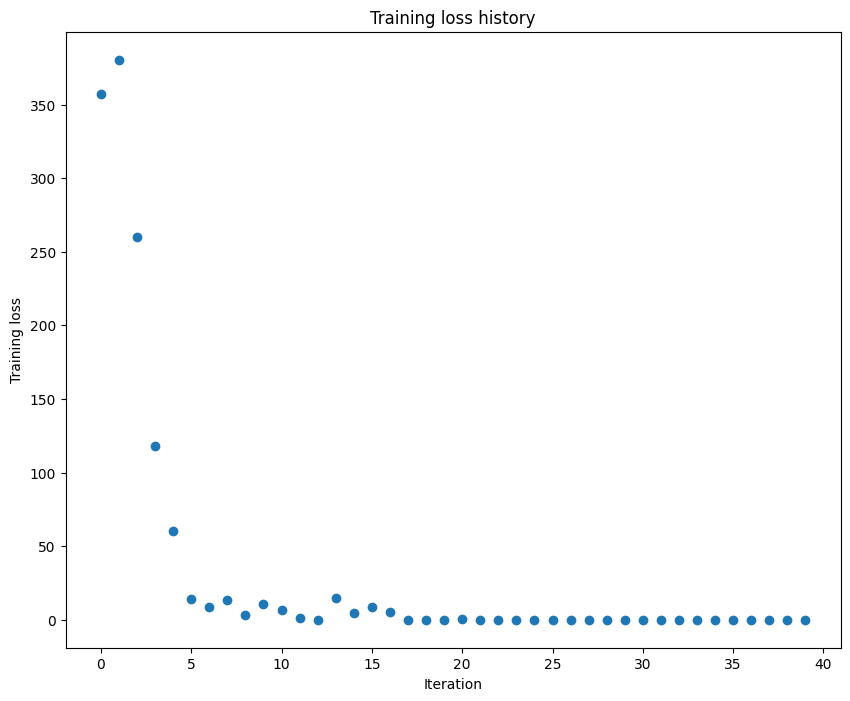

In [34]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 1e-1
learning_rate = 1e-3
model = FullyConnectedNet([100, 100],
              weight_scale=weight_scale, dtype=np.float64)
solver = Solver(model, small_data,
                print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd',
                optim_config={
                  'learning_rate': learning_rate,
                }
         )
solver.train()

plt.plot(solver.loss_history, 'o')
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.show()

Now try to use a five-layer network with 100 units on each layer to overfit 50 training examples. Again you will have to adjust the learning rate and weight initialization, but you should be able to achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 73.014739
(Epoch 0 / 20) train acc: 0.260000; val_acc: 0.125000
(Epoch 1 / 20) train acc: 0.200000; val_acc: 0.107000
(Epoch 2 / 20) train acc: 0.360000; val_acc: 0.115000
(Epoch 3 / 20) train acc: 0.420000; val_acc: 0.141000
(Epoch 4 / 20) train acc: 0.520000; val_acc: 0.150000
(Epoch 5 / 20) train acc: 0.700000; val_acc: 0.128000
(Iteration 11 / 40) loss: 1.069515
(Epoch 6 / 20) train acc: 0.860000; val_acc: 0.144000
(Epoch 7 / 20) train acc: 0.940000; val_acc: 0.146000
(Epoch 8 / 20) train acc: 0.980000; val_acc: 0.148000
(Epoch 9 / 20) train acc: 0.940000; val_acc: 0.140000
(Epoch 10 / 20) train acc: 0.960000; val_acc: 0.149000
(Iteration 21 / 40) loss: 0.001461
(Epoch 11 / 20) train acc: 0.960000; val_acc: 0.149000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.137000
(Epoch 13 / 20) train acc: 0.980000; val_acc: 0.147000
(Epoch 14 / 20) train acc: 0.960000; val_acc: 0.140000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.140000
(Iteration 31 / 40) loss:

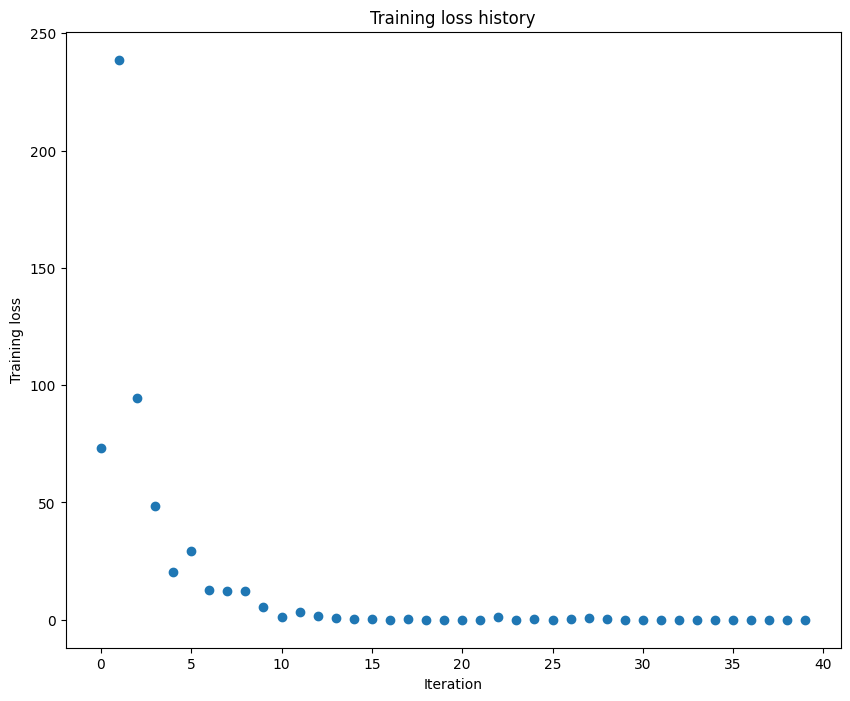

In [40]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 2e-3
weight_scale = 1e-1
model = FullyConnectedNet([100, 100, 100, 100],
                weight_scale=weight_scale, dtype=np.float64)
solver = Solver(model, small_data,
                print_every=10, num_epochs=20, batch_size=25,
                update_rule='sgd',
                optim_config={
                  'learning_rate': learning_rate,
                }
         )
solver.train()

plt.plot(solver.loss_history, 'o')
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.show()

## Inline Question 2:
Did you notice anything about the comparative difficulty of training the three-layer net vs training the five layer net? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:
Training a five-layer network is generally more difficult than a three-layer network because deeper networks are significantly more sensitive to the **initialization scale** (`weight_scale`).

In a deeper network, the signal passes through more layers; if the weights are slightly too large, the activations and gradients can explode. If they are slightly too small, they can vanish before reaching the earlier layers. This multiplicative effect across layers means that the 'sweet spot' for initialization is much narrower for a 5-layer net than for a 3-layer net.

While the 5-layer net may overfit a tiny dataset faster due to its higher capacity (more parameters), it is much easier to run into numerical instability or stagnant learning if the parameters are not perfectly tuned.

# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.

# SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.

In [42]:
from cs231n.optim import sgd_momentum
import os

# Implementation of sgd_momentum to be written to cs231n/optim.py
optim_path = 'cs231n/optim.py'
with open(optim_path, 'r') as f:
    lines = f.readlines()

new_lines = []
skip = False
for line in lines:
    if 'def sgd_momentum(w, dw, config=None):' in line:
        new_lines.append(line)
        new_lines.append("    if config is None: config = {}\n")
        new_lines.append("    learning_rate = config.get('learning_rate', 1e-2)\n")
        new_lines.append("    momentum = config.get('momentum', 0.9)\n")
        new_lines.append("    v = config.get('velocity', np.zeros_like(w))\n")
        new_lines.append("    next_w = None\n")
        new_lines.append("    ###############################################################################\n")
        new_lines.append("    # TODO: Implement the momentum update formula.                                #\n")
        new_lines.append("    ###############################################################################\n")
        new_lines.append("    v = momentum * v - learning_rate * dw\n")
        new_lines.append("    next_w = w + v\n")
        new_lines.append("    ###############################################################################\n")
        new_lines.append("    #                             END OF YOUR CODE                                #\n")
        new_lines.append("    ###############################################################################\n")
        new_lines.append("    config['velocity'] = v\n")
        new_lines.append("    return next_w, config\n")
        skip = True
    elif skip and line.strip().startswith('return'):
        skip = False
        continue
    elif not skip:
        new_lines.append(line)

with open(optim_path, 'w') as f:
    f.writelines(new_lines)

import importlib
import cs231n.optim
importlib.reload(cs231n.optim)
from cs231n.optim import sgd_momentum

# Now run the test again
N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-3, 'velocity': v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

print('next_w error: ', rel_error(next_w, expected_next_w))
print('velocity error: ', rel_error(expected_velocity, config['velocity']))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

running with  sgd
(Iteration 1 / 200) loss: 2.922261
(Epoch 0 / 5) train acc: 0.121000; val_acc: 0.127000
(Iteration 11 / 200) loss: 2.191477
(Iteration 21 / 200) loss: 2.004417
(Iteration 31 / 200) loss: 2.242215
(Epoch 1 / 5) train acc: 0.307000; val_acc: 0.293000
(Iteration 41 / 200) loss: 2.081681
(Iteration 51 / 200) loss: 2.025854
(Iteration 61 / 200) loss: 1.920495
(Iteration 71 / 200) loss: 1.861366
(Epoch 2 / 5) train acc: 0.345000; val_acc: 0.308000
(Iteration 81 / 200) loss: 1.854677
(Iteration 91 / 200) loss: 1.879993
(Iteration 101 / 200) loss: 1.797267
(Iteration 111 / 200) loss: 1.779265
(Epoch 3 / 5) train acc: 0.372000; val_acc: 0.315000
(Iteration 121 / 200) loss: 1.834504
(Iteration 131 / 200) loss: 1.664358
(Iteration 141 / 200) loss: 1.464464
(Iteration 151 / 200) loss: 1.864444
(Epoch 4 / 5) train acc: 0.378000; val_acc: 0.298000
(Iteration 161 / 200) loss: 1.798305
(Iteration 171 / 200) loss: 1.509775
(Iteration 181 / 200) loss: 1.734281
(Iteration 191 / 200) los

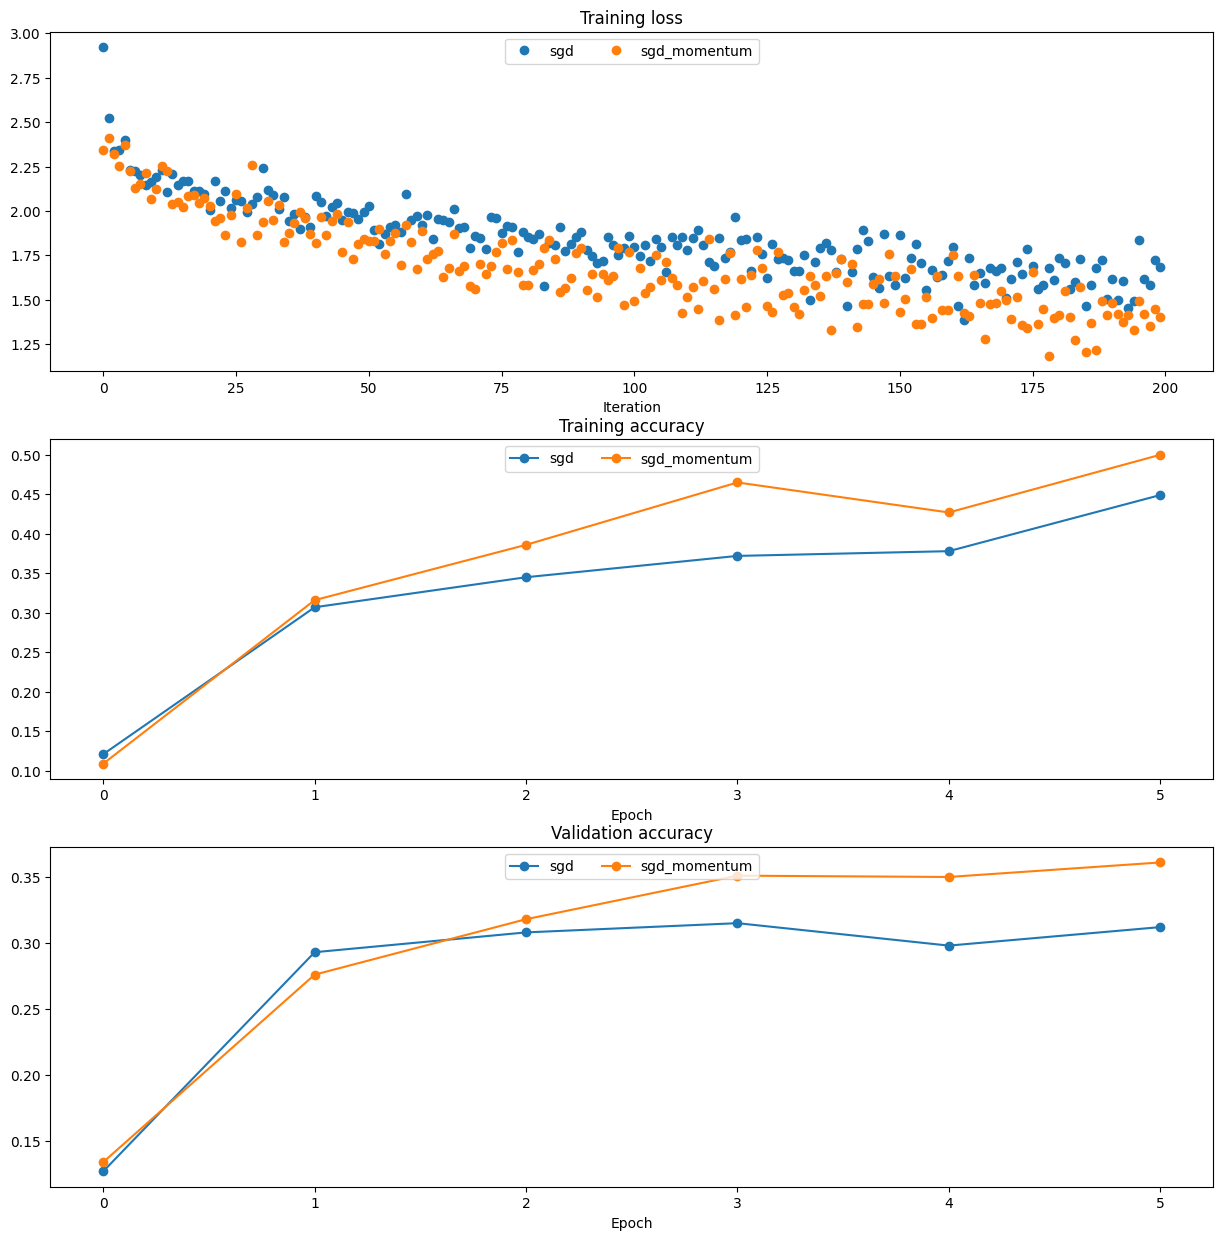

In [53]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
  print('running with ', update_rule)
  model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

  solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': 1e-2,
                  },
                  verbose=True)
  solvers[update_rule] = solver
  solver.train()
  print()

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Epoch')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Epoch')

for update_rule, solver in list(solvers.items()):
  plt.subplot(3, 1, 1)
  plt.plot(solver.loss_history, 'o', label=update_rule)

  plt.subplot(3, 1, 2)
  plt.plot(solver.train_acc_history, '-o', label=update_rule)

  plt.subplot(3, 1, 3)
  plt.plot(solver.val_acc_history, '-o', label=update_rule)

for i in [1, 2, 3]:
  plt.subplot(3, 1, i)
  plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()

# RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [45]:
# Implement RMSProp and Adam in cs231n/optim.py
optim_path = 'cs231n/optim.py'
with open(optim_path, 'r') as f:
    lines = f.readlines()

new_lines = []
current_func = None

for line in lines:
    if 'def rmsprop(w, dw, config=None):' in line:
        current_func = 'rmsprop'
        new_lines.append(line)
        new_lines.append("    if config is None: config = {}\n")
        new_lines.append("    config.setdefault('learning_rate', 1e-2)\n")
        new_lines.append("    config.setdefault('decay_rate', 0.99)\n")
        new_lines.append("    config.setdefault('epsilon', 1e-8)\n")
        new_lines.append("    config.setdefault('cache', np.zeros_like(w))\n")
        new_lines.append("    config['cache'] = config['decay_rate'] * config['cache'] + (1 - config['decay_rate']) * (dw**2)\n")
        new_lines.append("    next_w = w - config['learning_rate'] * dw / (np.sqrt(config['cache']) + config['epsilon'])\n")
        new_lines.append("    return next_w, config\n")
    elif 'def adam(w, dw, config=None):' in line:
        current_func = 'adam'
        new_lines.append(line)
        new_lines.append("    if config is None: config = {}\n")
        new_lines.append("    config.setdefault('learning_rate', 1e-3)\n")
        new_lines.append("    config.setdefault('beta1', 0.9)\n")
        new_lines.append("    config.setdefault('beta2', 0.999)\n")
        new_lines.append("    config.setdefault('epsilon', 1e-8)\n")
        new_lines.append("    config.setdefault('m', np.zeros_like(w))\n")
        new_lines.append("    config.setdefault('v', np.zeros_like(w))\n")
        new_lines.append("    config.setdefault('t', 0)\n")
        new_lines.append("    config['t'] += 1\n")
        new_lines.append("    config['m'] = config['beta1'] * config['m'] + (1 - config['beta1']) * dw\n")
        new_lines.append("    config['v'] = config['beta2'] * config['v'] + (1 - config['beta2']) * (dw**2)\n")
        new_lines.append("    mb = config['m'] / (1 - config['beta1']**config['t'])\n")
        new_lines.append("    vb = config['v'] / (1 - config['beta2']**config['t'])\n")
        new_lines.append("    next_w = w - config['learning_rate'] * mb / (np.sqrt(vb) + config['epsilon'])\n")
        new_lines.append("    return next_w, config\n")
    elif current_func and (line.strip().startswith('return') or 'pass' in line):
        current_func = None
        continue
    elif not current_func:
        new_lines.append(line)

with open(optim_path, 'w') as f:
    f.writelines(new_lines)

import importlib
import cs231n.optim
importlib.reload(cs231n.optim)
from cs231n.optim import rmsprop, adam

# Test RMSProp implementation
N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])

print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  0.005022232473552954


In [46]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

running with  adam
(Iteration 1 / 200) loss: 2.757791
(Epoch 0 / 5) train acc: 0.119000; val_acc: 0.112000
(Iteration 11 / 200) loss: 2.061309
(Iteration 21 / 200) loss: 1.928992
(Iteration 31 / 200) loss: 1.855026
(Epoch 1 / 5) train acc: 0.350000; val_acc: 0.296000
(Iteration 41 / 200) loss: 1.747192
(Iteration 51 / 200) loss: 1.977861
(Iteration 61 / 200) loss: 1.729552
(Iteration 71 / 200) loss: 1.659949
(Epoch 2 / 5) train acc: 0.445000; val_acc: 0.332000
(Iteration 81 / 200) loss: 1.526775
(Iteration 91 / 200) loss: 1.449236
(Iteration 101 / 200) loss: 1.340427
(Iteration 111 / 200) loss: 1.471777
(Epoch 3 / 5) train acc: 0.469000; val_acc: 0.348000
(Iteration 121 / 200) loss: 1.343383
(Iteration 131 / 200) loss: 1.444561
(Iteration 141 / 200) loss: 1.369479
(Iteration 151 / 200) loss: 1.426220
(Epoch 4 / 5) train acc: 0.536000; val_acc: 0.364000
(Iteration 161 / 200) loss: 1.382259
(Iteration 171 / 200) loss: 1.452647
(Iteration 181 / 200) loss: 1.089244
(Iteration 191 / 200) lo

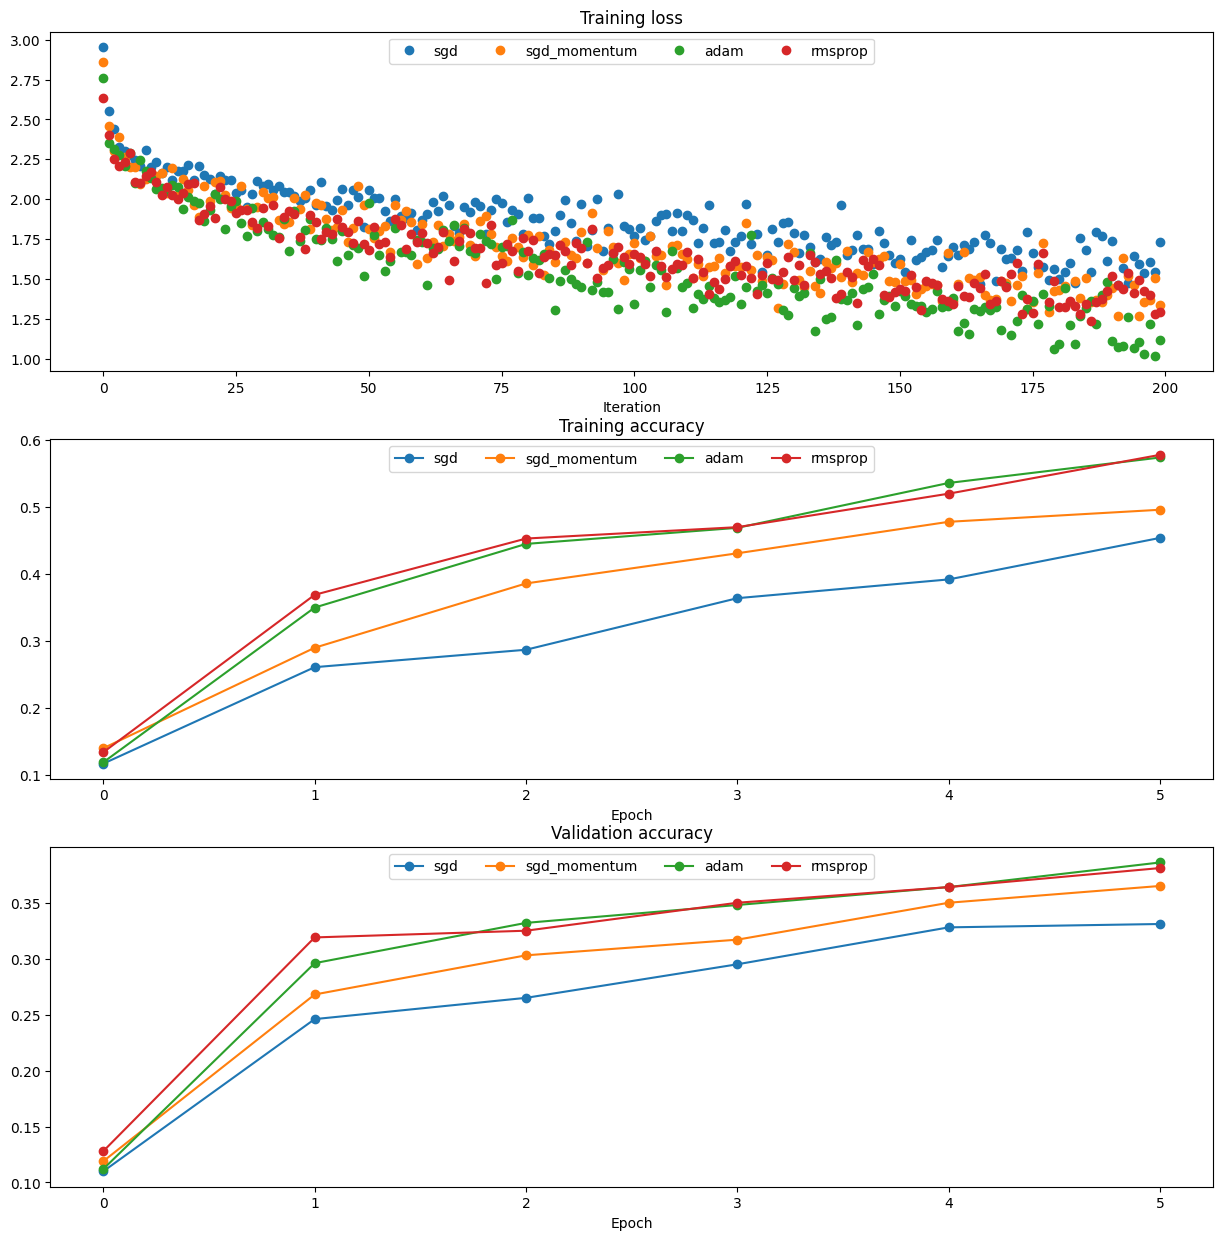

In [47]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
  print('running with ', update_rule)
  model = FullyConnectedNet([100, 100, 100, 100, 100], weight_scale=5e-2)

  solver = Solver(model, small_data,
                  num_epochs=5, batch_size=100,
                  update_rule=update_rule,
                  optim_config={
                    'learning_rate': learning_rates[update_rule]
                  },
                  verbose=True)
  solvers[update_rule] = solver
  solver.train()
  print()

plt.subplot(3, 1, 1)
plt.title('Training loss')
plt.xlabel('Iteration')

plt.subplot(3, 1, 2)
plt.title('Training accuracy')
plt.xlabel('Epoch')

plt.subplot(3, 1, 3)
plt.title('Validation accuracy')
plt.xlabel('Epoch')

for update_rule, solver in list(solvers.items()):
  plt.subplot(3, 1, 1)
  plt.plot(solver.loss_history, 'o', label=update_rule)

  plt.subplot(3, 1, 2)
  plt.plot(solver.train_acc_history, '-o', label=update_rule)

  plt.subplot(3, 1, 3)
  plt.plot(solver.val_acc_history, '-o', label=update_rule)

for i in [1, 2, 3]:
  plt.subplot(3, 1, i)
  plt.legend(loc='upper center', ncol=4)
plt.gcf().set_size_inches(15, 15)
plt.show()

## Inline Question 3:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


## Answer:

**AdaGrad issue:** The problem with AdaGrad is that the `cache` (the sum of squares of historical gradients) increases monotonically throughout training. As it grows, the effective learning rate `learning_rate / (np.sqrt(cache) + eps)` decreases continually. Eventually, the steps become so infinitesimally small that the network stops learning entirely, even if it hasn't reached an optimum.

**Adam comparison:** Adam (and RMSProp) avoids this specific issue by using an **exponentially decaying average** of squared gradients rather than a simple cumulative sum. This allows the optimizer to 'forget' very old gradients and ensures that the denominator doesn't grow indefinitely. Consequently, Adam maintains more stable and effective update sizes throughout the entire training process.

# Train a good model!
Train the best fully-connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully-connected net.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the assignment we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional nets rather than fully-connected nets.

You might find it useful to complete the `BatchNormalization.ipynb` and `Dropout.ipynb` notebooks before completing this part, since those techniques can help you train powerful models.

In [48]:
best_model = None
################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################

hidden_dims = [100] * 4

range_weight_scale = [1e-2, 2e-2, 5e-3]
range_lr = [1e-5, 5e-4, 1e-5]

best_val_acc = -1
best_weight_scale = 0
best_lr = 0

print("Training...")

for weight_scale in range_weight_scale:
    for lr in range_lr:
        model = FullyConnectedNet(hidden_dims=hidden_dims, reg=0.0,
                                 weight_scale=weight_scale)
        solver = Solver(model, data, update_rule='adam',
                        optim_config={'learning_rate': lr},
                        batch_size=100, num_epochs=5,
                        verbose=False)
        solver.train()
        val_acc = solver.best_val_acc

        print('Weight_scale: %f, lr: %f, val_acc: %f' % (weight_scale, lr, val_acc))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weight_scale = weight_scale
            best_lr = lr
            best_model = model

print("Best val_acc: %f" % best_val_acc)
print("Best weight_scale: %f" % best_weight_scale)
print("Best lr: %f" % best_lr)

################################################################################
#                              END OF YOUR CODE                                #
################################################################################

Training...
Weight_scale: 0.010000, lr: 0.000010, val_acc: 0.329000
Weight_scale: 0.010000, lr: 0.000500, val_acc: 0.520000
Weight_scale: 0.010000, lr: 0.000010, val_acc: 0.336000
Weight_scale: 0.020000, lr: 0.000010, val_acc: 0.406000
Weight_scale: 0.020000, lr: 0.000500, val_acc: 0.518000
Weight_scale: 0.020000, lr: 0.000010, val_acc: 0.411000
Weight_scale: 0.005000, lr: 0.000010, val_acc: 0.217000
Weight_scale: 0.005000, lr: 0.000500, val_acc: 0.510000
Weight_scale: 0.005000, lr: 0.000010, val_acc: 0.291000
Best val_acc: 0.520000
Best weight_scale: 0.010000
Best lr: 0.000500


# Test your model!
Run your best model on the validation and test sets. You should achieve above 50% accuracy on the validation set.

In [49]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.52
Test set accuracy:  0.528
